In [1]:
!pip install transformers -U

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazonreviews' dataset.
Path to dataset files: /kaggle/input/amazonreviews


In [3]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [4]:
# décompresser jeu d’entraînement pour le lire avec pandas
import pandas as pd
import bz2

def decompress_bz2(file_path, output_path):
    with bz2.open(file_path, 'rt', encoding='utf-8') as file:
        with open(output_path, 'w', encoding='utf-8') as out_file:
            out_file.write(file.read())

# Decompress the files
decompress_bz2('/kaggle/input/amazonreviews/train.ft.txt.bz2', 'train.ft.txt')

In [5]:
# transforme ton fichier texte brut en un tableau propre

def parse_data(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            label, text = line.split(' ', 1)
            label = int(label.replace('__label__', ''))
            data.append((label, text.strip()))
    return pd.DataFrame(data, columns=['label', 'text'])

In [6]:
train = parse_data('train.ft.txt')

train.head(60)

,label,text
0,2,Stuning even for the non-gamer: This sound tra...
1,2,The best soundtrack ever to anything.: I'm rea...
2,2,Amazing!: This soundtrack is my favorite music...
3,2,Excellent Soundtrack: I truly like this soundt...
4,2,"Remember, Pull Your Jaw Off The Floor After He..."
5,2,an absolute masterpiece: I am quite sure any o...
6,1,"Buyer beware: This is a self-published book, a..."
7,2,Glorious story: I loved Whisper of the wicked ...
8,2,A FIVE STAR BOOK: I just finished reading Whis...
9,2,Whispers of the Wicked Saints: This was a easy...


In [7]:
# préparer les labels pour l’entraînement du modèle de classification binaire

df = train.copy()
df.label = df.label.map({2:0, 1:1})  # 1 are negatives (targeted class)
df

,label,text
0,0,Stuning even for the non-gamer: This sound tra...
1,0,The best soundtrack ever to anything.: I'm rea...
2,0,Amazing!: This soundtrack is my favorite music...
3,0,Excellent Soundtrack: I truly like this soundt...
4,0,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
3599995,1,Don't do it!!: The high chair looks great when...
3599996,1,"Looks nice, low functionality: I have used thi..."
3599997,1,"compact, but hard to clean: We have a small ho..."
3599998,1,what is it saying?: not sure what this book is...


label
0    1800000
1    1800000
Name: count, dtype: int64


<Axes: xlabel='label'>

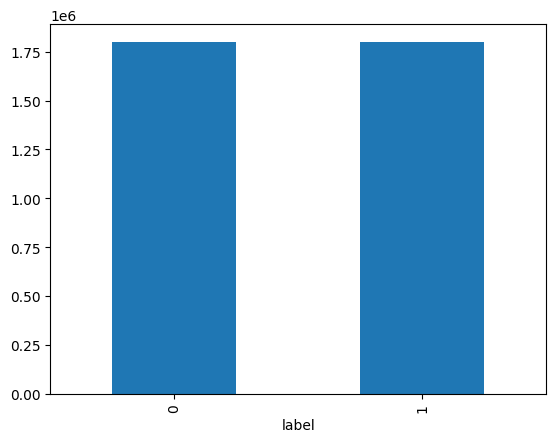

In [8]:
# équilibrer les classes avant l'entrainement

print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar')

In [9]:
# bibliothèque de pretraitement des textes

!pip install spacy

In [10]:
# on va reduire data à 40000 pour rendre l'entrainement vite
df = df[0:40000]
df

,label,text
0,0,Stuning even for the non-gamer: This sound tra...
1,0,The best soundtrack ever to anything.: I'm rea...
2,0,Amazing!: This soundtrack is my favorite music...
3,0,Excellent Soundtrack: I truly like this soundt...
4,0,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
39995,1,Far too basic Visual Basic: The book boasts In...
39996,0,Excellent product: I would highly recommend th...
39997,0,"Made my old hose like new!: I have an old, hea..."
39998,0,wish I knew it was this easy: I went way to lo...


label
0    20344
1    19656
Name: count, dtype: int64


<Axes: xlabel='label'>

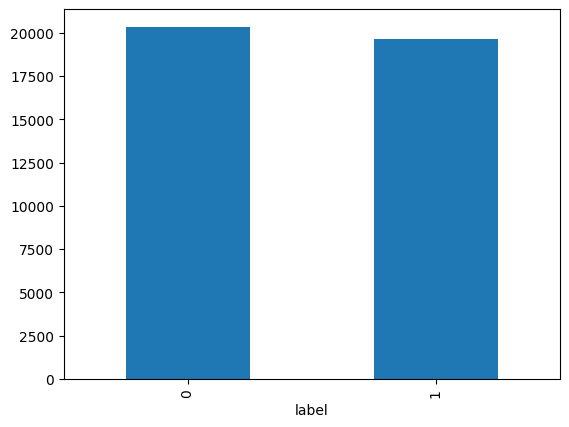

In [11]:
# Data is balanced
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar')

In [12]:
# identifier automatiquement les aspects à partir des avis

import spacy

# Aspect Extraction using spaCy
nlp = spacy.load('en_core_web_sm')
def extract_aspects(text):
    doc = nlp(text)
    aspects = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"]]
    return aspects if aspects else ["General"]  # If no aspect found, assign 'General'

df['aspects'] = df['text'].apply(extract_aspects)

/tmp/ipython-input-1741695433.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['aspects'] = df['text'].apply(extract_aspects)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    40000 non-null  int64 
 1   text     40000 non-null  object
 2   aspects  40000 non-null  object
dtypes: int64(1), object(2)
memory usage: 937.6+ KB


label
0    20344
1    19656
Name: count, dtype: int64


<Axes: xlabel='label'>

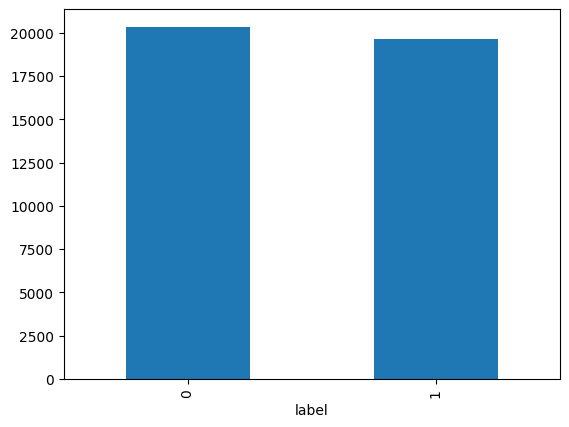

In [14]:
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar')

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import torch
from transformers import TrainingArguments, Trainer
from transformers import TrainingArguments, Trainer, BertTokenizer, BertForSequenceClassification
from transformers import EarlyStoppingCallback

In [16]:
# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
# Split data
X = df["text"].tolist()
y = df["label"].tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Tokenize dataset
X_train_tokenized = tokenizer(X_train, padding=True, truncation=True, max_length=512, return_tensors="pt")
X_test_tokenized = tokenizer(X_test, padding=True, truncation=True, max_length=512, return_tensors="pt")

In [18]:
# Convert to PyTorch Dataset
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [19]:
train_dataset = Dataset(X_train_tokenized, y_train)
test_dataset = Dataset(X_test_tokenized, y_test)

train_dataset[3]

/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


{'input_ids': tensor([  101,  2025,  2919,  2005,  1037, 10036,  5442,   999,  1024, 10036,
          1010,  2422,  3635,  1010,  3243, 12379,  1010,  2987,  1005,  1056,
          2907,  1037,  4629,  3341,  2200,  2092,  1011,  2021,  2054,  2079,
          2017,  5987,  2013,  1037, 10036,  5442,  1029,  1045,  4149,  2009,
          2138,  1045,  4669,  1996,  4338,   999,  2224,  2009,  1010,  6905,
          2009,  2059,  5466,  2009,  2185,  2030,  5271,  2012,  2115,  2279,
          1000,  1045,  1005,  2222,  2196,  2079,  2009,  2153,  1000,  7381,
          5096,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [20]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions),
    }

In [21]:
# Define Trainer

args = TrainingArguments(
    output_dir="output",  # This is fine
    run_name="bert_sentiment_analysis",  # Explicitly setting a meaningful run name
    num_train_epochs=1,
    per_device_train_batch_size=8,
    logging_dir="./logs",  # Optional: Define logging directory for TensorBoard
)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Step,Training Loss
500,0.371600
1000,0.285700
1500,0.282600
2000,0.244600
2500,0.222600
3000,0.198400
3500,0.196900
4000,0.183600


/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct fro

TrainOutput(global_step=4000, training_loss=0.24825276184082032, metrics={'train_runtime': 2492.6407, 'train_samples_per_second': 12.838, 'train_steps_per_second': 1.605, 'total_flos': 6150220919040000.0, 'train_loss': 0.24825276184082032, 'epoch': 1.0})

In [22]:
!pip install wandb

In [23]:
trainer.evaluate()

/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


{'eval_loss': 0.19672618806362152,
 'eval_accuracy': 0.94975,
 'eval_precision': 0.9551199380964663,
 'eval_recall': 0.9419994912236073,
 'eval_f1': 0.9485143442622951,
 'eval_runtime': 180.3955,
 'eval_samples_per_second': 44.347,
 'eval_steps_per_second': 5.543,
 'epoch': 1.0}

/tmp/ipython-input-2131402086.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


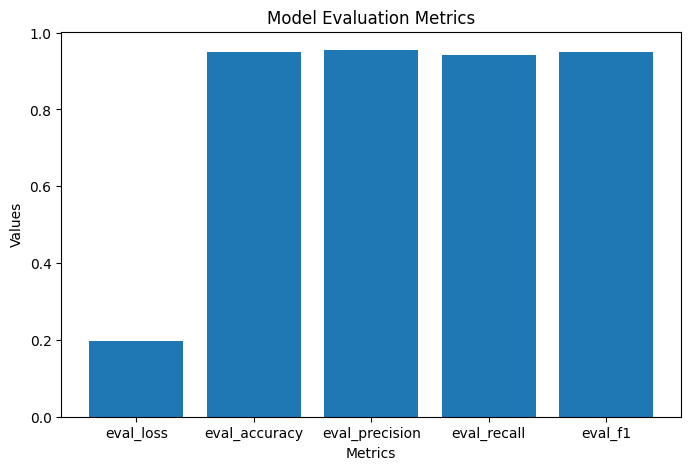

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Evaluate the model
evaluation_results = trainer.evaluate()

metrics = ["eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]
values = [evaluation_results.get(metric, 0) for metric in metrics]

plt.figure(figsize=(8,5))
plt.bar(metrics, values)
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("Model Evaluation Metrics")
plt.show()

In [27]:
import torch
import re

def classify_text(text, model, tokenizer):
    # Split the text into separate sentences using commas or periods
    sentences = re.split(r'[,.]', text)

    results = []

    for sentence in sentences:
        sentence = sentence.strip()
        if sentence:  # Ignore empty strings
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model.to(device)
            inputs = tokenizer(sentence, padding=True, truncation=True, return_tensors='pt').to(device)

            with torch.no_grad():
                outputs = model(**inputs)

            predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

            predictions = predictions.cpu().detach().numpy()
            aspects = extract_aspects(sentence)

            sentiment = "Positive" if predictions[0][0] > 0.5 else "Negative"

            print(f"Sentence: {sentence}")
            print(f"Extracted Aspects: {aspects}")
            print(f"Predicted Sentiment: {sentiment}")

            results.append((sentence, sentiment, aspects))

    return results

predictions = classify_text("The packaging was good, but the product is bad.", model, tokenizer)

Sentence: The packaging was good
Extracted Aspects: ['packaging']
Predicted Sentiment: Positive
Sentence: but the product is bad
Extracted Aspects: ['product']
Predicted Sentiment: Negative


In [28]:
predictions = classify_text("The mobile is bad", model, tokenizer)

Sentence: The mobile is bad
Extracted Aspects: ['mobile']
Predicted Sentiment: Negative


In [29]:
predictions = classify_text("""After purchasing such an expensive item we do not expect such damaged item box.
The box was damaged in various places and had tape applied on the front. I don't know whether the damage was
due to the box falling or not. I am also confused whether the box and PS5 might have suffered any damage due to the fall.
I am not satisfied. You have to give proper box packing without any damage.""", model, tokenizer)

Sentence: After purchasing such an expensive item we do not expect such damaged item box
Extracted Aspects: ['item', 'item', 'box']
Predicted Sentiment: Negative
Sentence: The box was damaged in various places and had tape applied on the front
Extracted Aspects: ['box', 'places', 'tape', 'front']
Predicted Sentiment: Negative
Sentence: I don't know whether the damage was
due to the box falling or not
Extracted Aspects: ['damage', 'box']
Predicted Sentiment: Negative
Sentence: I am also confused whether the box and PS5 might have suffered any damage due to the fall
Extracted Aspects: ['box', 'PS5', 'damage', 'fall']
Predicted Sentiment: Negative
Sentence: I am not satisfied
Extracted Aspects: ['General']
Predicted Sentiment: Negative
Sentence: You have to give proper box packing without any damage
Extracted Aspects: ['box', 'packing', 'damage']
Predicted Sentiment: Negative


In [30]:
model.save_pretrained("sentiment_model")
tokenizer.save_pretrained("sentiment_model")

('sentiment_model/tokenizer_config.json',
 'sentiment_model/special_tokens_map.json',
 'sentiment_model/vocab.txt',
 'sentiment_model/added_tokens.json')